In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
df = pd.read_csv(r"C:\Users\USER\Downloads\creditcard.csv")

print("Dataset loaded successfully!")
print(df.shape)

Dataset loaded successfully!
(284807, 31)


In [3]:
print(df.shape)
print(df.head())
print(df.info())


(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [4]:
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


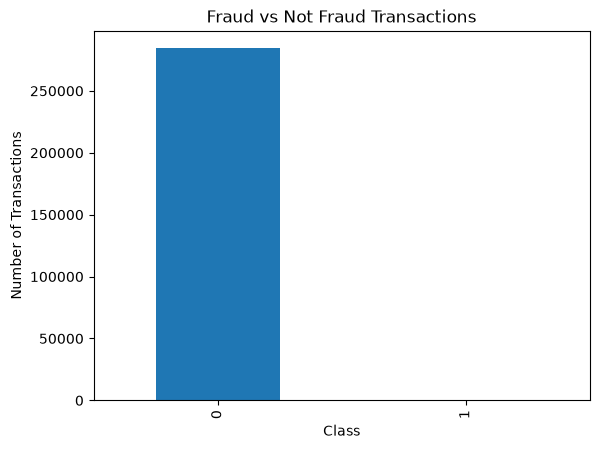

In [5]:
df["Class"].value_counts().plot(kind="bar")

plt.title("Fraud vs Not Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.show()

In [6]:
print(df["Amount"].describe())

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


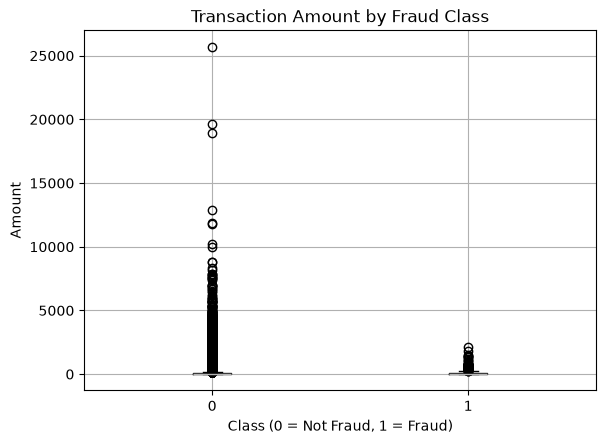

In [7]:
df.boxplot(column="Amount", by="Class")

plt.title("Transaction Amount by Fraud Class")
plt.suptitle("")
plt.xlabel("Class (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Amount")
plt.show()

In [8]:
fraud_df = df[df["Class"] == 1]

print(fraud_df.shape)

(492, 31)


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1081


In [10]:
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


In [11]:
df = df.drop_duplicates()

print("New dataset shape:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

New dataset shape: (283726, 31)
Remaining duplicates: 0


In [12]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (283726, 30)
y shape: (283726,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (226980, 30)
X_test: (56746, 30)
y_train: (226980,)
y_test: (56746,)


In [14]:
print("Training distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training distribution:
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Testing distribution:
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


In [15]:
print("Training class counts:")
print(y_train.value_counts())

print("\nTesting class counts:")
print(y_test.value_counts())

Training class counts:
Class
0    226602
1       378
Name: count, dtype: int64

Testing class counts:
Class
0    56651
1       95
Name: count, dtype: int64


In [16]:
print(X_train[["Time", "Amount"]].describe())

                Time         Amount
count  226980.000000  226980.000000
mean    94900.224390      88.387124
std     47488.214282     245.767046
min         0.000000       0.000000
25%     54241.750000       5.690000
50%     84816.000000      22.080000
75%    139364.250000      77.850000
max    172792.000000   19656.530000


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (226980, 30)
Scaled testing shape: (56746, 30)


In [18]:
class_weight="balanced"

In [19]:
from sklearn.linear_model import LogisticRegression

fraud_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

fraud_model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [20]:
fraud_predictions = fraud_model.predict(X_test_scaled)

print("Predictions:")
print(fraud_predictions[:20])

Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [21]:
print("Predicted class counts:")
print(pd.Series(fraud_predictions).value_counts())

Predicted class counts:
0    55274
1     1472
Name: count, dtype: int64


In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, fraud_predictions)

print(cm)

[[55262  1389]
 [   12    83]]


In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, fraud_predictions)
recall = recall_score(y_test, fraud_predictions)
f1 = f1_score(y_test, fraud_predictions)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.05638586956521739
Recall: 0.8736842105263158
F1 Score: 0.10593490746649649


In [24]:
from sklearn.metrics import roc_auc_score

fraud_probabilities = fraud_model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, fraud_probabilities)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9656548079701293


In [25]:
print(fraud_probabilities[:20])

[0.02162645 0.02007152 0.01024023 0.01572015 0.21923533 0.06080725
 0.02212544 0.03847994 0.08682055 0.00180108 0.03693569 0.10852574
 0.07071949 0.06983653 0.19443705 0.00906905 0.42714524 0.00608696
 0.09094212 0.07587578]


In [26]:
threshold_results = []

thresholds = [0.50, 0.60, 0.70, 0.80, 0.90]

for threshold in thresholds:
    predictions = (fraud_probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    cost = (fn * 100000) + (fp * 1000)

    threshold_results.append({
        "Threshold": threshold,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Business_Cost": cost
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df)

   Threshold  TP    FP  FN     TN  Precision    Recall        F1  \
0        0.5  83  1389  12  55262   0.056386  0.873684  0.105935   
1        0.6  83   970  12  55681   0.078822  0.873684  0.144599   
2        0.7  83   634  12  56017   0.115760  0.873684  0.204433   
3        0.8  80   419  15  56232   0.160321  0.842105  0.269360   
4        0.9  79   222  16  56429   0.262458  0.831579  0.398990   

   Business_Cost  
0        2589000  
1        2170000  
2        1834000  
3        1919000  
4        1822000  


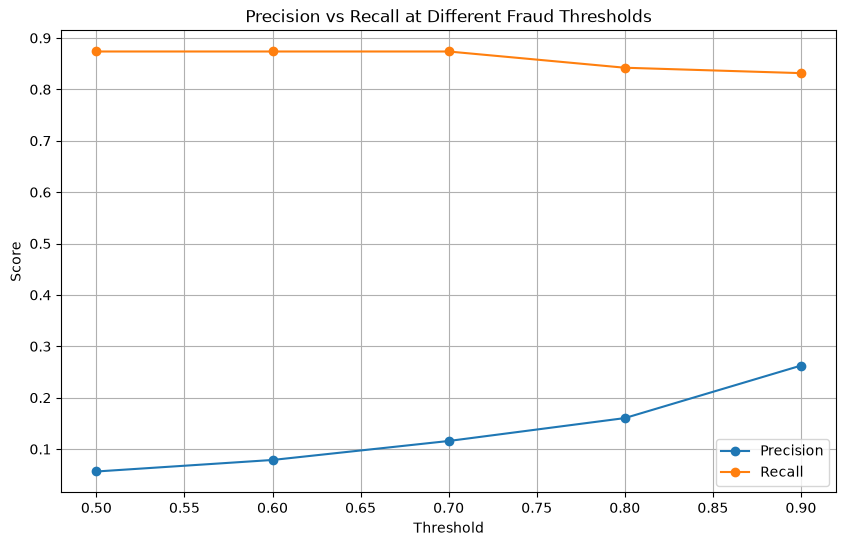

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall at Different Fraud Thresholds")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        fraud_predictions,
        target_names=["Not Fraud", "Fraud"],
        digits=4
    )
)

              precision    recall  f1-score   support

   Not Fraud     0.9998    0.9755    0.9875     56651
       Fraud     0.0564    0.8737    0.1059        95

    accuracy                         0.9753     56746
   macro avg     0.5281    0.9246    0.5467     56746
weighted avg     0.9982    0.9753    0.9860     56746



In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_fraud = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_fraud.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [30]:
rf_predictions = rf_fraud.predict(X_test)

print(rf_predictions[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [31]:
import numpy as np

unique, counts = np.unique(rf_predictions, return_counts=True)

print(dict(zip(unique, counts)))

{np.int64(0): np.int64(56673), np.int64(1): np.int64(73)}


In [32]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_predictions)

print(rf_cm)


[[56647     4]
 [   26    69]]


In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score

rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

Precision: 0.9452054794520548
Recall: 0.7263157894736842
F1 Score: 0.8214285714285714


In [34]:
from sklearn.metrics import roc_auc_score

rf_probabilities = rf_fraud.predict_proba(X_test)[:, 1]

rf_roc_auc = roc_auc_score(y_test, rf_probabilities)

print("Random Forest ROC-AUC:", rf_roc_auc)

Random Forest ROC-AUC: 0.9391009960338881


In [35]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [precision, rf_precision],
    "Recall": [recall, rf_recall],
    "F1 Score": [f1, rf_f1],
    "ROC-AUC": [roc_auc, rf_roc_auc]
})

print(comparison)

                 Model  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression   0.262458  0.831579  0.398990  0.965655
1        Random Forest   0.945205  0.726316  0.821429  0.939101


In [36]:
logistic_cost = (12 * 500000) + (1389 * 1000)
random_forest_cost = (26 * 500000) + (4 * 1000)

print("Logistic Regression Cost: ₦", logistic_cost)
print("Random Forest Cost: ₦", random_forest_cost)

Logistic Regression Cost: ₦ 7389000
Random Forest Cost: ₦ 13004000


In [37]:
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

for threshold in thresholds:

    predictions = (fraud_probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    cost = (fn * 500000) + (fp * 1000)

    print(
        f"Threshold: {threshold:.2f} | "
        f"FP: {fp} | "
        f"FN: {fn} | "
        f"Cost: ₦{cost:,}"
    )

Threshold: 0.10 | FP: 10162 | FN: 6 | Cost: ₦13,162,000
Threshold: 0.20 | FP: 5116 | FN: 8 | Cost: ₦9,116,000
Threshold: 0.30 | FP: 3019 | FN: 12 | Cost: ₦9,019,000
Threshold: 0.40 | FP: 1993 | FN: 12 | Cost: ₦7,993,000
Threshold: 0.50 | FP: 1389 | FN: 12 | Cost: ₦7,389,000
Threshold: 0.60 | FP: 970 | FN: 12 | Cost: ₦6,970,000
Threshold: 0.70 | FP: 634 | FN: 12 | Cost: ₦6,634,000
Threshold: 0.80 | FP: 419 | FN: 15 | Cost: ₦7,919,000
Threshold: 0.90 | FP: 222 | FN: 16 | Cost: ₦8,222,000


In [38]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_fraud.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

   Feature  Importance
14     V14    0.188663
10     V10    0.117722
12     V12    0.102422
17     V17    0.097098
4       V4    0.093188
3       V3    0.066788
11     V11    0.053492
16     V16    0.044913
2       V2    0.036496
9       V9    0.025199


In [39]:
logistic_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": fraud_model.coef_[0],
    "Absolute_Importance": abs(fraud_model.coef_[0])
})

logistic_importance = logistic_importance.sort_values(
    by="Absolute_Importance",
    ascending=False
)

print(logistic_importance.head(10))

   Feature  Coefficient  Absolute_Importance
29  Amount     1.621455             1.621455
14     V14    -1.497686             1.497686
1       V1     1.393505             1.393505
12     V12    -1.254749             1.254749
10     V10    -1.218284             1.218284
4       V4     1.207536             1.207536
5       V5     0.891382             0.891382
17     V17    -0.861413             0.861413
22     V22     0.663440             0.663440
20     V20    -0.650852             0.650852


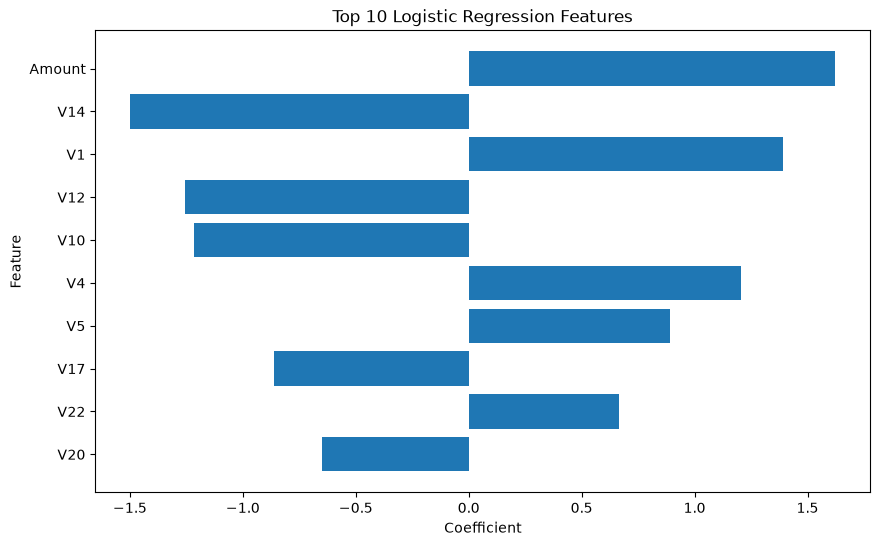

In [40]:
top_features = logistic_importance.head(10).sort_values(
    by="Absolute_Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Logistic Regression Features")

plt.show()